# Stage 4 — The Economics: What Will This Geothermal System Cost?

This notebook answers the question the whole challenge hinges on: **is the heat worth the money, and what is the cheapest way to build it?** We measure cost with **LCoE** — the *levelized cost of energy*, basically the all-in price of one unit of delivered energy once you spread the upfront drilling and equipment bills plus the yearly running costs across every joule the plant produces over its life. Lower LCoE = better deal. We first check our cost model against the organiser's reference spreadsheet, then search across designs for the **least-cost** one, and finally wrap the answer in a **Monte-Carlo risk band** — thousands of what-if runs that show how the cost moves when the underground rock turns out better or worse than expected.

Why it matters for the challenge: a low headline cost means nothing if a single unlucky well can blow up the budget. The economics here are what turn a promising resource into a defensible investment recommendation.

**How to run:** run the cells top to bottom. Everything needed is imported in the first code cell; the analysis pulls from the project's `geothermal` package, prints a few labelled tables, and saves three figures into the project's outputs folder.

## Setup

We import our plotting and numerics libraries plus the project's own `geothermal` package, which holds the validated cost and optimisation logic. We also create the folder where the figures will be saved. Nothing is computed yet — this just gets the tools on the table.

In [1]:
from __future__ import annotations

import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np

from geothermal import config
from geothermal.economics import (
    evaluate_candidate,
    lcoe_monte_carlo,
    levelized_cost_eur_per_gj,
    monte_carlo_lcoe_samples,
    optimize,
)

FIG_DIR = config.OUTPUTS_DIR / "figures" / "phase4"
FIG_DIR.mkdir(parents=True, exist_ok=True)

## Section 1 — Does our cost model match the official reference?

Before trusting any result, we sanity-check our LCoE formula against the organiser's supplied spreadsheet (`LCOE.xlsx`). We feed in the same base case — two wells delivering heat directly — and confirm our Python re-implementation lands on the same number. **Look for** our value matching the reference of 5.77 EUR/GJ (euros per gigajoule of delivered energy); a tick mark means the model is faithful and the rest of the notebook can be believed.

In [2]:
print("=" * 78)
print("SECTION 1 — LCoE PORT VALIDATION")
print("=" * 78)
base = levelized_cost_eur_per_gj(capex_eur=8_791_005, annual_opex_eur=566_433, annual_energy_gj=290_449)
print(f"  provided LCOE.xlsx base case (2 wells, direct heat): 5.77 EUR/GJ")
print(f"  our Python port:                                     {base:.2f} EUR/GJ  ✓")

SECTION 1 — LCoE PORT VALIDATION
  provided LCOE.xlsx base case (2 wells, direct heat): 5.77 EUR/GJ
  our Python port:                                     5.77 EUR/GJ  ✓


## Section 2 — Finding the cheapest design

Here we try a few plausible plant sizes and let cost decide. A **doublet** is a pair of wells — one to pump hot water up, one to send the cooled water back down — so this is essentially a sweep over "how many well-pairs do we drill?" (1, 2, or 3). For each option we report its geothermal capacity (in megawatts, MW), its LCoE, its upfront capital cost (CAPEX, in millions of euros), and how much of the demand still needs a gas/electric **backup**. The winner adds **HT-ATES** — high-temperature aquifer thermal energy storage, an underground "battery" for heat that banks summer warmth to use in winter. **Look for** the optimum: fewer wells plus storage beating brute-force drilling, which is exactly the hint the organisers dropped.

In [3]:
print("\n" + "=" * 78)
print("SECTION 2 — LEAST-LCoE DESIGN (sweep over doublet count)")
print("=" * 78)
candidates = [evaluate_candidate(n) for n in (1, 2, 3)]
print(f"  {'design':24} {'geo MW':>7} {'LCoE EUR/GJ':>12} {'CAPEX MEUR':>11} {'backup':>7}")
for c in candidates:
    tag = f"{c.n_doublets} doublet(s)" + (" + HT-ATES" if c.costs.capex_breakdown['ht_ates'] > 0 else "")
    print(f"  {tag:24} {c.geo_capacity_mw:7.1f} {c.lcoe_eur_per_gj:12.1f} {c.capex_meur:11.1f} {c.backup_fraction * 100:6.1f}%")
best = optimize()[0]
print(f"\n  OPTIMUM: {best.n_doublets} doublet(s) + HT-ATES → LCoE {best.lcoe_eur_per_gj:.1f} EUR/GJ "
      f"({best.lcoe_eur_per_gj * 3.6:.0f} EUR/MWh)")
print("  Fewer wells + seasonal storage beats more wells — exactly the organiser's hint.")


SECTION 2 — LEAST-LCoE DESIGN (sweep over doublet count)
  design                    geo MW  LCoE EUR/GJ  CAPEX MEUR  backup
  1 doublet(s) + HT-ATES       6.1         20.9        17.1    0.0%
  2 doublet(s)                12.3         29.5        29.0    0.0%
  3 doublet(s)                18.4         38.4        42.4    0.0%

  OPTIMUM: 1 doublet(s) + HT-ATES → LCoE 20.9 EUR/GJ (75 EUR/MWh)
  Fewer wells + seasonal storage beats more wells — exactly the organiser's hint.


## Section 3 — Selling cold as well as heat

The same system can deliver **cooling**, not just heating, by reusing the infrastructure. Because that cold counts as useful energy sold, it spreads the fixed costs over a bigger output and pushes the price-per-unit down. We compare LCoE when we count heat *and* cold versus heat alone. **Look for** the percentage drop — adding cooling makes every unit of energy cheaper.

In [4]:
print("\n" + "=" * 78)
print("SECTION 3 — COOLING INTEGRATION LOWERS LCoE")
print("=" * 78)
print(f"  LCoE over heat + cold : {best.costs.lcoe_eur_per_gj:.1f} EUR/GJ")
print(f"  LCoE over heat only   : {best.costs.lcoe_heat_only_eur_per_gj:.1f} EUR/GJ")
print(f"  → cooling cuts LCoE by {(1 - best.costs.lcoe_eur_per_gj / best.costs.lcoe_heat_only_eur_per_gj) * 100:.0f}%")


SECTION 3 — COOLING INTEGRATION LOWERS LCoE
  LCoE over heat + cold : 20.9 EUR/GJ
  LCoE over heat only   : 26.8 EUR/GJ
  → cooling cuts LCoE by 22%


## Section 4 — How risky is the cost? (Monte-Carlo)

A single best-guess number hides the real danger: we don't yet know how freely water flows through the rock — its **transmissivity** — and that drives the cost. So we run a **Monte-Carlo**: thousands of simulated builds, each with a different randomly-drawn rock quality, to map the full spread of outcomes. We summarise each design with **P10 / P50 / P90** — the optimistic, middle, and pessimistic cost levels (P90 means 90% of cases come in at or below it, i.e. a near-worst case). **Look for** the counter-intuitive result: a second well in the *same* geological trend does **not** spread the risk, because both wells succeed or fail together — so its bad-case P90 is actually worse. The takeaway is a **staged** plan: build one doublet plus storage, test the rock, then expand only if the data justify it.

In [5]:
print("\n" + "=" * 78)
print("SECTION 4 — MONTE-CARLO LCoE (transmissivity uncertainty)")
print("=" * 78)
band1 = lcoe_monte_carlo(1, n_samples=3000)
band2 = lcoe_monte_carlo(2, n_samples=3000)
print(f"  1 doublet : P10 {band1['p10']:.1f} | P50 {band1['p50']:.1f} | P90 {band1['p90']:.1f} EUR/GJ")
print(f"  2 doublets: P10 {band2['p10']:.1f} | P50 {band2['p50']:.1f} | P90 {band2['p90']:.1f} EUR/GJ")
print("\n  KEY INSIGHT: a 2nd well in the SAME trend does NOT de-risk — the wells share the")
print(f"  same (correlated) geology, so the 2-doublet P90 ({band2['p90']:.0f}) is WORSE than the")
print(f"  1-doublet P90 ({band1['p90']:.0f}): a bad outcome just doubles the wasted well cost.")
print("  RECOMMENDATION: a STAGED strategy — drill 1 doublet + HT-ATES (least LCoE), well-test")
print("  to resolve the wide transmissivity uncertainty, and expand only if data warrant it.")


SECTION 4 — MONTE-CARLO LCoE (transmissivity uncertainty)


  1 doublet : P10 16.8 | P50 21.2 | P90 36.9 EUR/GJ
  2 doublets: P10 21.8 | P50 29.7 | P90 62.3 EUR/GJ

  KEY INSIGHT: a 2nd well in the SAME trend does NOT de-risk — the wells share the
  same (correlated) geology, so the 2-doublet P90 (62) is WORSE than the
  1-doublet P90 (37): a bad outcome just doubles the wasted well cost.
  RECOMMENDATION: a STAGED strategy — drill 1 doublet + HT-ATES (least LCoE), well-test
  to resolve the wide transmissivity uncertainty, and expand only if data warrant it.


### Figure 1 — Cost by design

A bar chart of LCoE for each design, with the winning option highlighted in green. **Look for** the shortest green bar — the cheapest plant — confirming the table in Section 2 at a glance.

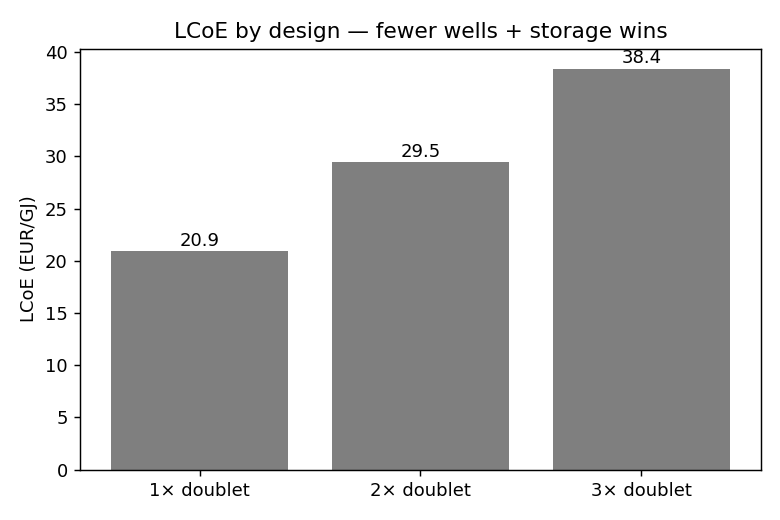

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
labels = [f"{c.n_doublets}× doublet" for c in candidates]
lcoes = [c.lcoe_eur_per_gj for c in candidates]
colors = ["tab:green" if c is best else "tab:gray" for c in candidates]
ax.bar(labels, lcoes, color=colors)
for i, v in enumerate(lcoes):
    ax.text(i, v + 0.5, f"{v:.1f}", ha="center")
ax.set_ylabel("LCoE (EUR/GJ)")
ax.set_title("LCoE by design — fewer wells + storage wins")
fig.tight_layout()
fig.savefig(FIG_DIR / "lcoe_by_design.png", dpi=130)

from IPython.display import Image as _Image
_Image(str(FIG_DIR / "lcoe_by_design.png"))

### Figure 2 — The cost-risk band

A histogram of the thousands of Monte-Carlo outcomes for the winning design, with dashed lines marking the P10 (green), P50 (black), and P90 (red) cost levels. **Look for** how wide the spread is and how far the pessimistic P90 tail sits from the middle — that width *is* the resource risk we need to manage.

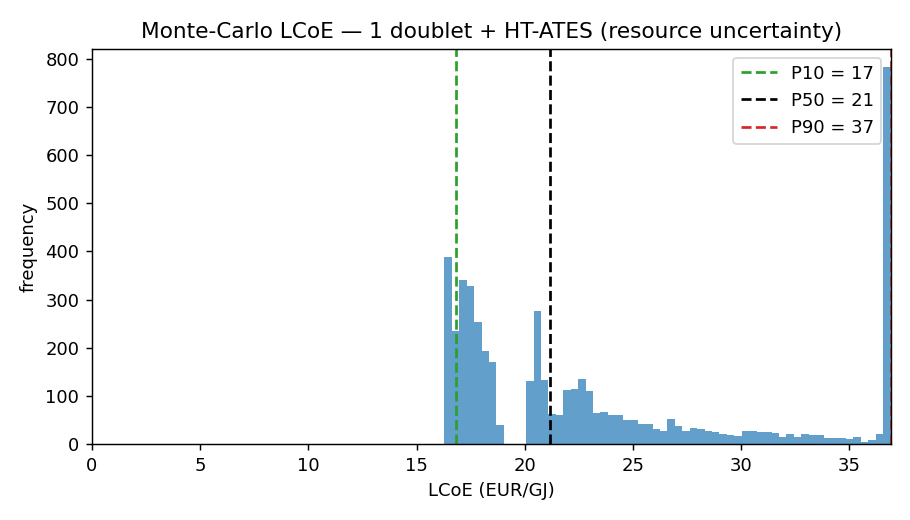

In [7]:
samples = monte_carlo_lcoe_samples(best.n_doublets, n_samples=5000)
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(samples, bins=60, color="tab:blue", alpha=0.7)
for pct, label, color in [(10, "P10", "tab:green"), (50, "P50", "k"), (90, "P90", "tab:red")]:
    v = float(np.percentile(samples, pct))
    ax.axvline(v, color=color, ls="--", label=f"{label} = {v:.0f}")
ax.set_xlabel("LCoE (EUR/GJ)")
ax.set_ylabel("frequency")
ax.set_title(f"Monte-Carlo LCoE — {best.n_doublets} doublet + HT-ATES (resource uncertainty)")
ax.legend()
ax.set_xlim(0, np.percentile(samples, 99))
fig.tight_layout()
fig.savefig(FIG_DIR / "lcoe_monte_carlo.png", dpi=130)

from IPython.display import Image as _Image
_Image(str(FIG_DIR / "lcoe_monte_carlo.png"))

### Figure 3 — Where the upfront money goes

A horizontal bar chart breaking the winning design's CAPEX (upfront capital cost) into its pieces — drilling, equipment, storage, and so on. **Look for** which item dominates the bill; that's the line to scrutinise and the lever with the most room to cut cost.


Figures written to /Users/vadmin/Documents/Lab/Projects/DSEATS/June26GeoDatathon/outputs/figures/phase4


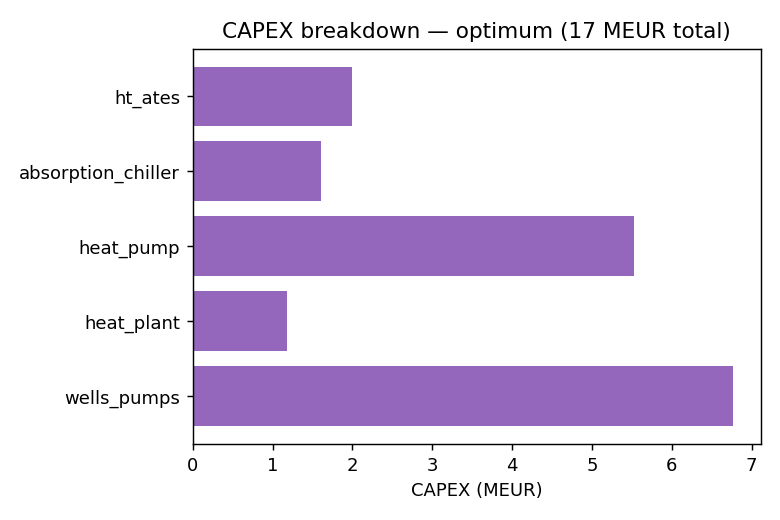

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
items = {k: v for k, v in best.costs.capex_breakdown.items() if v > 0.01}
ax.barh(list(items.keys()), list(items.values()), color="tab:purple")
ax.set_xlabel("CAPEX (MEUR)")
ax.set_title(f"CAPEX breakdown — optimum ({best.capex_meur:.0f} MEUR total)")
fig.tight_layout()
fig.savefig(FIG_DIR / "capex_breakdown.png", dpi=130)

print(f"\nFigures written to {FIG_DIR}")

from IPython.display import Image as _Image
_Image(str(FIG_DIR / "capex_breakdown.png"))